# Students Performance Dataset - Tasks 3, 4, and 5

This notebook applies the DecodeLabs data science instructions to `StudentsPerformance.csv`:

- Task 3: Exploratory Data Analysis (EDA)
- Task 4: Data Visualization
- Task 5: Predictive Model or Insight Project

## Setup: Import Libraries and Load the Dataset

First, we import the needed libraries, load the dataset, and create two helpful columns: `total_score` and `average_score`.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")

file_path = "StudentsPerformance.csv"
df = pd.read_csv(file_path)

df["total_score"] = df[["math score", "reading score", "writing score"]].sum(axis=1)
df["average_score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


# Task 3: Exploratory Data Analysis (EDA)

## Step 1: Check Dataset Shape, Columns, and Data Types

This step gives a quick understanding of the dataset structure before deeper analysis.

In [10]:
print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())
print("Data types:")
print(df.dtypes)

Dataset shape: (1000, 10)
Columns:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score', 'total_score', 'average_score']
Data types:
gender                             str
race/ethnicity                     str
parental level of education        str
lunch                              str
test preparation course            str
math score                       int64
reading score                    int64
writing score                    int64
total_score                      int64
average_score                  float64
dtype: object


## Step 2: Check Missing Values and Duplicates

Before analysis, we confirm whether there are missing or duplicated records that could affect the results.

In [11]:
print("Missing values per column:")
print(df.isnull().sum())
print("Number of duplicated rows:", df.duplicated().sum())

Missing values per column:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
total_score                    0
average_score                  0
dtype: int64
Number of duplicated rows: 0


## Step 3: Calculate Basic Statistics

The numerical summary shows the central tendency and spread of math, reading, writing, total, and average scores.

In [12]:
df[["math score", "reading score", "writing score", "total_score", "average_score"]].describe().round(2)

,math score,reading score,writing score,total_score,average_score
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05,203.31,67.77
std,15.16,14.60,15.20,42.77,14.26
min,0.00,17.00,10.00,27.00,9.00
25%,57.00,59.00,57.75,175.00,58.33
50%,66.00,70.00,69.00,205.00,68.33
75%,77.00,79.00,79.00,233.00,77.67
max,100.00,100.00,100.00,300.00,100.00


## Step 4: Analyze Categorical Features

This step shows the distribution of students across gender, race/ethnicity, parental education, lunch type, and test preparation course.

In [13]:
categorical_columns = ["gender", "race/ethnicity", "parental level of education", "lunch", "test preparation course"]

for col in categorical_columns:
    print(f"{col}")
    print(df[col].value_counts())

gender
gender
female    518
male      482
Name: count, dtype: int64
race/ethnicity
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
parental level of education
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
lunch
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
test preparation course
test preparation course
none         642
completed    358
Name: count, dtype: int64


## Step 5: Compare Average Scores by Important Groups

Here, we compare average performance by gender, lunch type, test preparation course, parental education, and race/ethnicity.

In [14]:
print("Average scores by gender:")
display(df.groupby("gender")[["math score", "reading score", "writing score", "average_score"]].mean().round(2))

print("Average scores by lunch type:")
display(df.groupby("lunch")[["math score", "reading score", "writing score", "average_score"]].mean().round(2))

print("Average scores by test preparation course:")
display(df.groupby("test preparation course")[["math score", "reading score", "writing score", "average_score"]].mean().round(2))

print("Average score by parental level of education:")
display(df.groupby("parental level of education")["average_score"].mean().sort_values(ascending=False).round(2))

print("Average score by race/ethnicity:")
display(df.groupby("race/ethnicity")["average_score"].mean().sort_values(ascending=False).round(2))

Average scores by gender:


,math score,reading score,writing score,average_score
gender,,,,
female,63.63,72.61,72.47,69.57
male,68.73,65.47,63.31,65.84


Average scores by lunch type:


,math score,reading score,writing score,average_score
lunch,,,,
free/reduced,58.92,64.65,63.02,62.20
standard,70.03,71.65,70.82,70.84


Average scores by test preparation course:


,math score,reading score,writing score,average_score
test preparation course,,,,
completed,69.70,73.89,74.42,72.67
none,64.08,66.53,64.50,65.04


Average score by parental level of education:


parental level of education
master's degree       73.60
bachelor's degree     71.92
associate's degree    69.57
some college          68.48
some high school      65.11
high school           63.10
Name: average_score, dtype: float64

Average score by race/ethnicity:


race/ethnicity
group E    72.75
group D    69.18
group C    67.13
group B    65.47
group A    62.99
Name: average_score, dtype: float64

## Step 6: Identify Trends and Outliers

The IQR method is used to detect unusually low or high values in each score column.

In [15]:
score_columns = ["math score", "reading score", "writing score", "average_score"]
outlier_summary = []

for col in score_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary.append({
        "column": col,
        "lower_bound": round(lower_bound, 2),
        "upper_bound": round(upper_bound, 2),
        "outlier_count": len(outliers),
        "lowest_outlier": outliers[col].min() if len(outliers) > 0 else None,
        "highest_outlier": outliers[col].max() if len(outliers) > 0 else None
    })

pd.DataFrame(outlier_summary)

,column,lower_bound,upper_bound,outlier_count,lowest_outlier,highest_outlier
0,math score,27.00,107.00,8,0.0,26.0
1,reading score,29.00,109.00,6,17.0,28.0
2,writing score,25.88,110.88,5,10.0,23.0
3,average_score,29.33,106.67,6,9.0,26.0


## Task 3 Findings Summary

- The dataset has 1000 student records and no missing values.
- Reading has the highest average score at about 69.17, followed by writing at 68.05 and math at 66.09.
- Female students have higher reading and writing averages, while male students have a higher math average.
- Students who completed the test preparation course have a higher average score, about 72.67 compared with 65.04 for students who did not complete it.
- Students with standard lunch have a much higher average score, about 70.84 compared with 62.20 for students with free/reduced lunch.
- Reading and writing scores are very strongly correlated, suggesting that students who perform well in reading usually perform well in writing too.
- Outliers mainly appear as very low score values, especially in math and average score.

# Task 4: Data Visualization

## Step 1: Visualize Score Distributions

Histograms help show the spread and shape of math, reading, writing, and average scores.

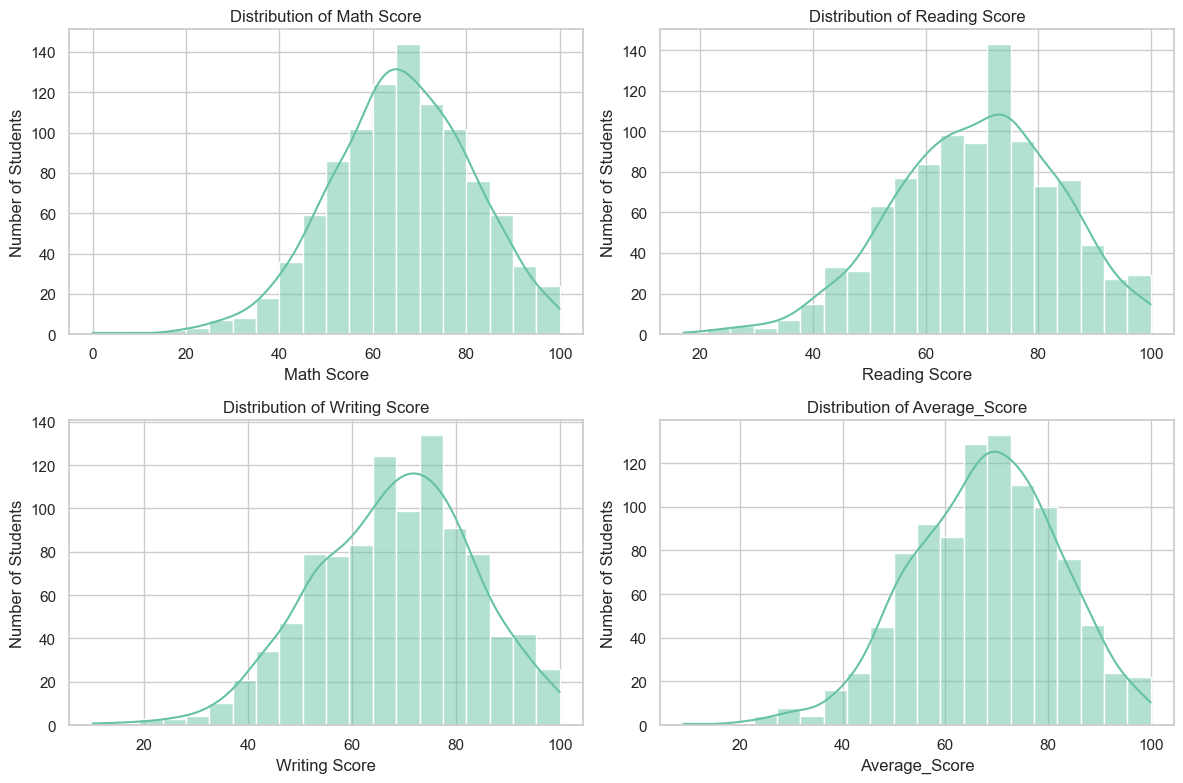

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
columns_to_plot = ["math score", "reading score", "writing score", "average_score"]

for ax, col in zip(axes.flatten(), columns_to_plot):
    sns.histplot(df[col], kde=True, ax=ax, bins=20)
    ax.set_title(f"Distribution of {col.title()}")
    ax.set_xlabel(col.title())
    ax.set_ylabel("Number of Students")

plt.tight_layout()
plt.show()

## Step 2: Compare Average Scores by Test Preparation Course

This chart highlights the impact of completing the test preparation course on overall student performance.

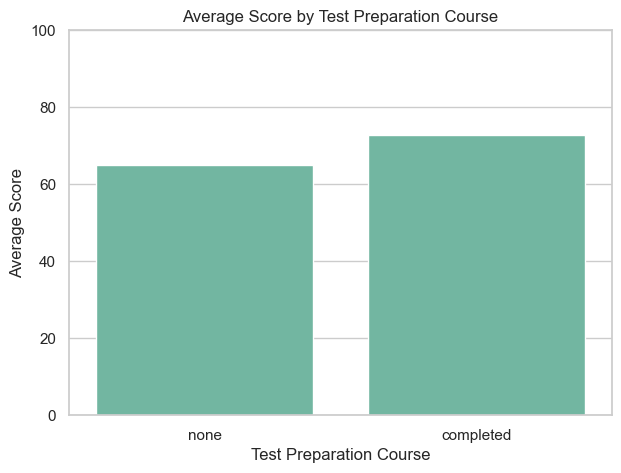

In [17]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="test preparation course", y="average_score", errorbar=None)
plt.title("Average Score by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.ylim(0, 100)
plt.show()

## Step 3: Compare Scores by Lunch Type

Lunch type can be used as a rough socioeconomic indicator, so this visualization compares performance by lunch category.

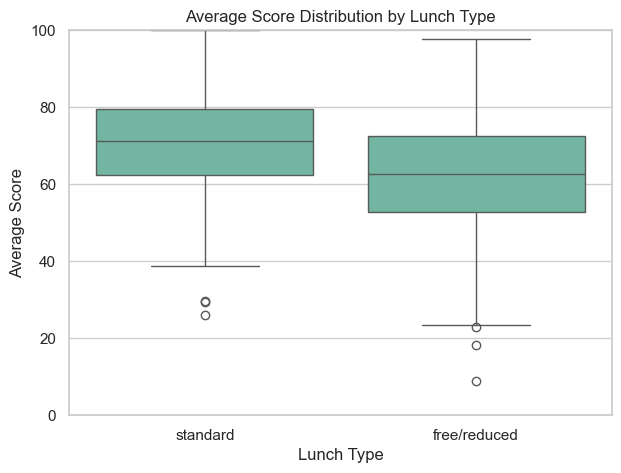

In [18]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="lunch", y="average_score")
plt.title("Average Score Distribution by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")
plt.ylim(0, 100)
plt.show()

## Step 4: Compare Subject Scores by Gender

This grouped chart shows how math, reading, and writing scores differ between female and male students.

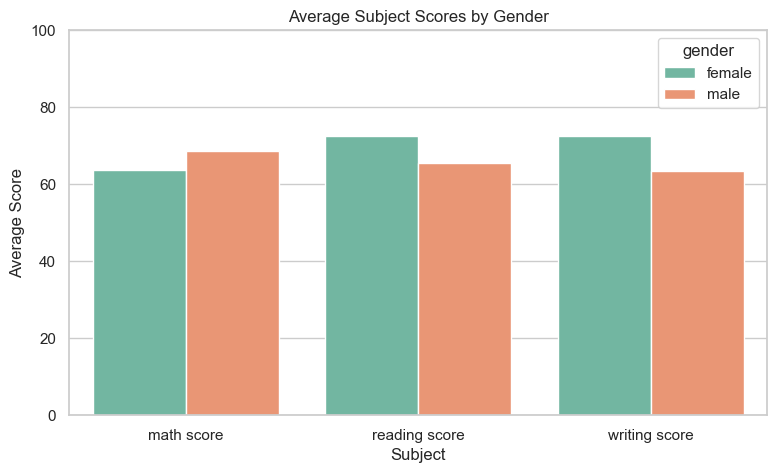

In [19]:
gender_scores = df.groupby("gender")[["math score", "reading score", "writing score"]].mean().reset_index()
gender_scores_melted = gender_scores.melt(id_vars="gender", var_name="subject", value_name="average_score")

plt.figure(figsize=(9, 5))
sns.barplot(data=gender_scores_melted, x="subject", y="average_score", hue="gender")
plt.title("Average Subject Scores by Gender")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.ylim(0, 100)
plt.show()

## Step 5: Visualize Average Score by Parental Education

This chart checks whether parental education level is connected to student performance.

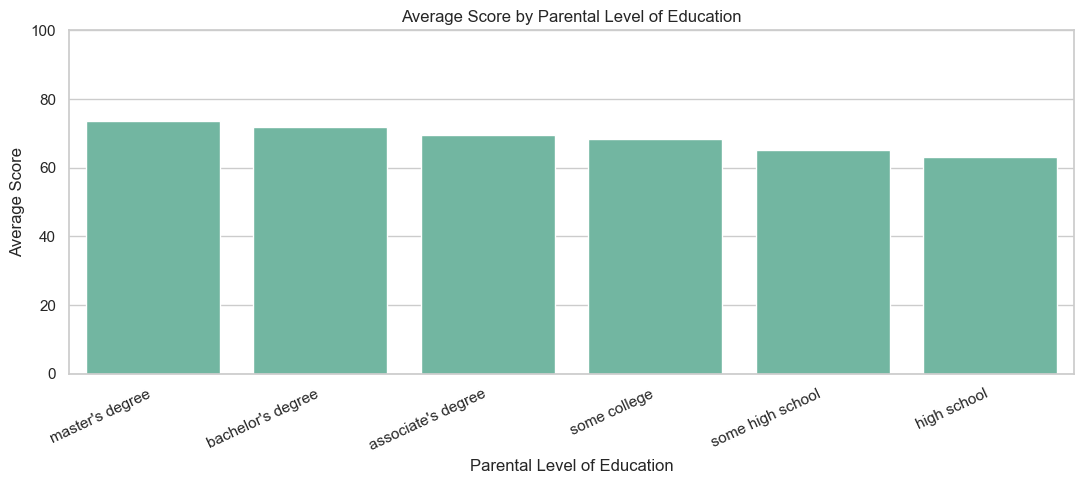

In [20]:
edu_order = df.groupby("parental level of education")["average_score"].mean().sort_values(ascending=False).index

plt.figure(figsize=(11, 5))
sns.barplot(data=df, x="parental level of education", y="average_score", order=edu_order, errorbar=None)
plt.title("Average Score by Parental Level of Education")
plt.xlabel("Parental Level of Education")
plt.ylabel("Average Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## Step 6: Show Correlation Between Subject Scores

The heatmap shows how strongly the three subject scores move together.

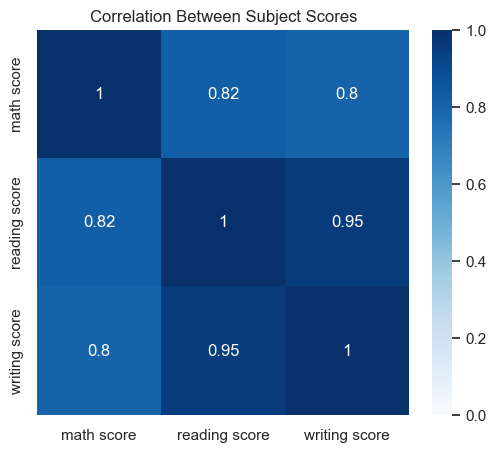

In [21]:
plt.figure(figsize=(6, 5))
correlation_matrix = df[["math score", "reading score", "writing score"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Correlation Between Subject Scores")
plt.show()

## Task 4 Visualization Insights

- Score distributions are mostly centered around the 60-80 range.
- Completing the test preparation course is associated with better average performance.
- Standard lunch students generally score higher than free/reduced lunch students.
- Female students score higher in reading and writing, while male students score higher in math.
- Higher parental education levels, especially master's and bachelor's degrees, are associated with higher average scores.
- Reading and writing have the strongest relationship, with a correlation of about 0.95.

# Task 5: Predictive Model or Insight Project

## Step 1: Define the Prediction Goal

The goal is to build a simple regression model that predicts `writing score` using `math score` and `reading score`.

This target makes sense because reading and writing have a very strong relationship, and math can add extra performance information.

## Step 2: Prepare Train and Test Data

We split the data manually into 80 percent training data and 20 percent testing data.

In [22]:
X = df[["math score", "reading score"]].to_numpy(dtype=float)
y = df["writing score"].to_numpy(dtype=float)

rng = np.random.default_rng(42)
indices = np.arange(len(df))
rng.shuffle(indices)

train_size = int(0.8 * len(df))
train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 800
Testing rows: 200


## Step 3: Train a Simple Linear Regression Model

This model uses the normal least-squares solution through `numpy.linalg.lstsq`, so it does not require `scikit-learn`.

In [23]:
X_train_with_bias = np.c_[np.ones(len(X_train)), X_train]
coefficients = np.linalg.lstsq(X_train_with_bias, y_train, rcond=None)[0]

intercept, math_coef, reading_coef = coefficients

print("Model equation:")
print(f"writing score = {intercept:.2f} + ({math_coef:.2f} * math score) + ({reading_coef:.2f} * reading score)")

Model equation:
writing score = -1.24 + (0.07 * math score) + (0.94 * reading score)


## Step 4: Evaluate the Model

We evaluate the model using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared.

In [24]:
X_test_with_bias = np.c_[np.ones(len(X_test)), X_test]
y_pred = X_test_with_bias @ coefficients

mae = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
r2 = 1 - (np.sum((y_test - y_pred) ** 2) / np.sum((y_test - y_test.mean()) ** 2))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R-squared: {r2:.3f}")

MAE: 3.46
RMSE: 4.34
R-squared: 0.915


## Step 5: Visualize Actual vs Predicted Writing Scores

This scatter plot compares the true writing scores with the predicted writing scores.

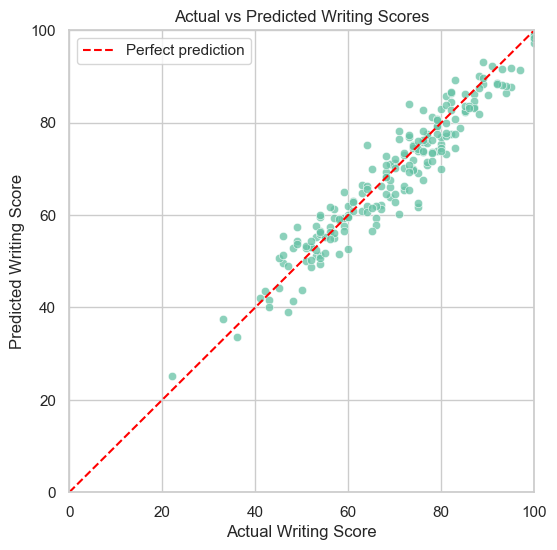

In [25]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.75)
plt.plot([0, 100], [0, 100], color="red", linestyle="--", label="Perfect prediction")
plt.title("Actual vs Predicted Writing Scores")
plt.xlabel("Actual Writing Score")
plt.ylabel("Predicted Writing Score")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend()
plt.show()

## Step 6: Generate Insight-Based Recommendations

Based on the EDA, visualizations, and prediction model, these recommendations can help improve student performance.

In [26]:
recommendations = [
    "Encourage more students to complete the test preparation course because completed students have higher average scores.",
    "Provide extra academic support for students with free/reduced lunch, since their average score is lower than standard lunch students.",
    "Use reading performance as an early indicator for writing performance because reading and writing are strongly correlated.",
    "Give targeted math support to students with very low math scores, since math has the lowest average and the largest low-end outliers.",
    "Monitor students with low average scores early, especially those below the IQR outlier threshold."
]

for i, rec in enumerate(recommendations, start=1):
    print(f"{i}. {rec}")

1. Encourage more students to complete the test preparation course because completed students have higher average scores.
2. Provide extra academic support for students with free/reduced lunch, since their average score is lower than standard lunch students.
3. Use reading performance as an early indicator for writing performance because reading and writing are strongly correlated.
4. Give targeted math support to students with very low math scores, since math has the lowest average and the largest low-end outliers.
5. Monitor students with low average scores early, especially those below the IQR outlier threshold.


## Task 5 Model and Insight Summary

A simple linear regression model was used to predict writing score from math and reading scores. The model achieved:

- MAE: about 3.46 points
- RMSE: about 4.34 points
- R-squared: about 0.915

This means the model explains about 91.5 percent of the variation in writing scores on the test split. Reading score is the strongest predictor because its coefficient is much larger than the math score coefficient, which matches the strong correlation between reading and writing.

The most important practical insight is that preparation, lunch type, and reading performance are strongly connected to overall student performance.